# **Data Preprocessing**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv('BankLoanApproval.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,IA35XVH6ZO,28,140466,163781,652,94,2,9.08,48,0.23,High School,Unemployed,Married,No,No,Education,No,0
1,Y8UETC3LSG,28,149227,139759,375,56,3,5.84,36,0.80,PhD,Full-time,Divorced,No,No,Education,Yes,1
2,RM6QSRHIYP,41,23265,63527,829,87,4,9.73,60,0.45,Master's,Full-time,Divorced,Yes,No,Auto,Yes,0
3,GX5YQOGROM,53,117550,95744,395,112,4,3.58,24,0.73,High School,Unemployed,Single,No,No,Auto,Yes,0
4,X0BVPZLDC0,57,139699,88143,635,112,4,5.63,48,0.20,Master's,Part-time,Divorced,No,No,Home,No,0


In [7]:
df.shape

(255327, 18)

In [8]:
# Get information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255327 entries, 0 to 255326
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255327 non-null  object 
 1   Age             255327 non-null  int64  
 2   Income          255327 non-null  int64  
 3   LoanAmount      255327 non-null  int64  
 4   CreditScore     255327 non-null  int64  
 5   MonthsEmployed  255327 non-null  int64  
 6   NumCreditLines  255327 non-null  int64  
 7   InterestRate    255327 non-null  float64
 8   LoanTerm        255327 non-null  int64  
 9   DTIRatio        255327 non-null  float64
 10  Education       255327 non-null  object 
 11  EmploymentType  255327 non-null  object 
 12  MaritalStatus   255327 non-null  object 
 13  HasMortgage     255327 non-null  object 
 14  HasDependents   255327 non-null  object 
 15  LoanPurpose     255327 non-null  object 
 16  HasCoSigner     255327 non-null  object 
 17  Default   

In [9]:
# Summary statistics of numerical columns
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255327.000000,255327.000000,255327.000000,255327.000000,255327.000000,255327.000000,255327.000000,255327.000000,255327.000000,255327.000000
mean,43.498059,82500.225585,127579.236559,574.266125,59.542516,2.501036,13.492848,36.025896,0.500222,0.116118
std,14.990304,38963.150663,70841.308245,158.904496,34.643129,1.117021,6.636456,16.969297,0.230917,0.320367
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48826.000000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82467.000000,127557.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188986.500000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [10]:
# Check for missing values
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [11]:
# Remove duplicates data
df.drop_duplicates(inplace=True)

In [12]:
for i in df.select_dtypes("object"):
    print(df[i].value_counts())
    print("-"*40)

LoanID
IA35XVH6ZO    1
1MIOJ7EYYE    1
DOHNEOD77T    1
5JJHTNLMAT    1
8NCCZEHHBY    1
             ..
RXVN35AP28    1
7GPO6AA0K8    1
A8UPH5CWHS    1
50YGC0NUFH    1
NUUI6CJDZ9    1
Name: count, Length: 255327, dtype: int64
----------------------------------------
Education
Bachelor's     64360
High School    63895
Master's       63538
PhD            63534
Name: count, dtype: int64
----------------------------------------
EmploymentType
Part-time        64156
Unemployed       63819
Self-employed    63702
Full-time        63650
Name: count, dtype: int64
----------------------------------------
MaritalStatus
Married     85295
Divorced    85024
Single      85008
Name: count, dtype: int64
----------------------------------------
HasMortgage
Yes    127664
No     127663
Name: count, dtype: int64
----------------------------------------
HasDependents
Yes    127735
No     127592
Name: count, dtype: int64
----------------------------------------
LoanPurpose
Business     51296
Home         5128

In [13]:
#df.drop("LoanID",axis=1).groupby("Income").describe().T

In [14]:
num_list=['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
cat_list=['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

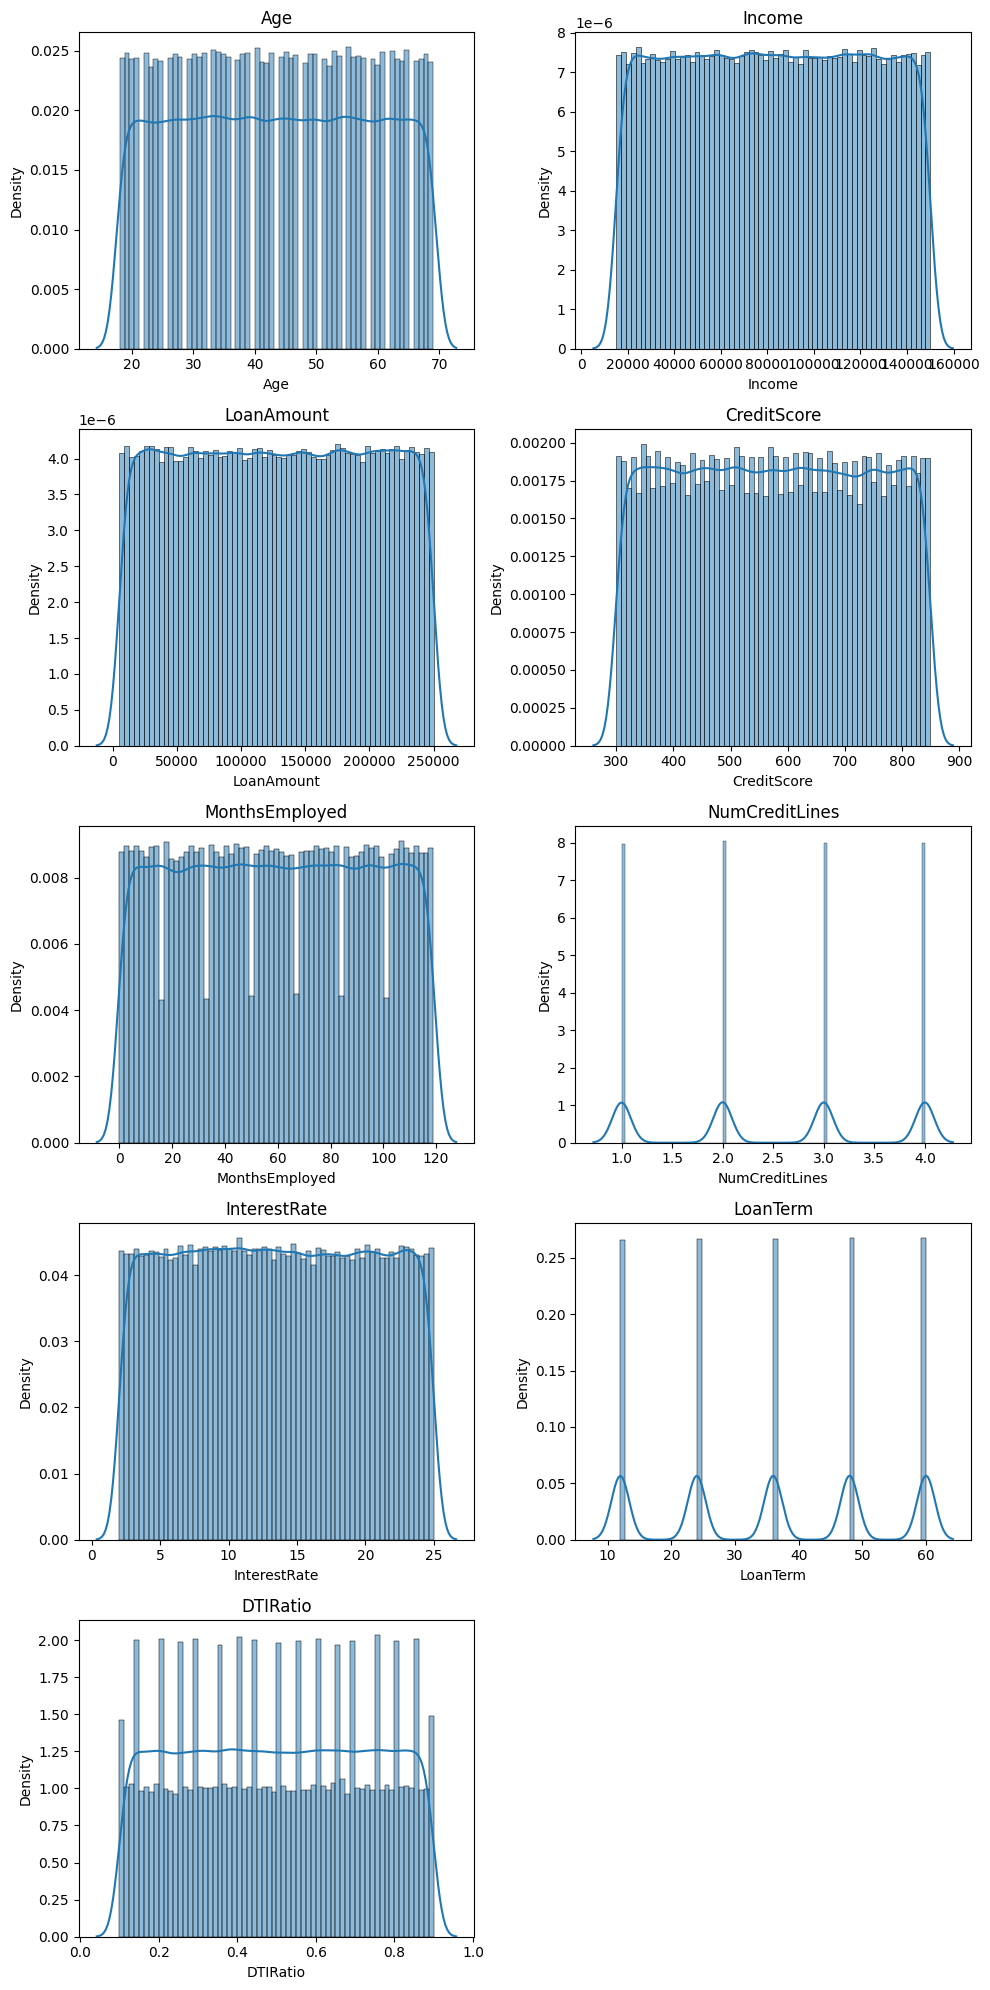

In [15]:
k=1
plt.figure(figsize=(10,20))
for i in df.loc[:,num_list]:
    plt.subplot(5,2,k)
    sns.histplot(df[i], kde=True, stat="density", kde_kws=dict(cut=3))
    plt.title(i)
    plt.tight_layout()
    k+=1

In [16]:
#Test outliers
for i in df.loc[:,num_list]:
    Q1 = df[i].quantile(0.15)
    Q3 = df[i].quantile(0.85)
    IQR = Q3-Q1
    up = Q3 + 1.5*IQR
    low = Q1 - 1.5*IQR

    if df[(df[i] > up) | (df[i] < low)].any(axis=None):
        print(i,": yes")
    else:
        print(i, ": no")

Age : no
Income : no
LoanAmount : no
CreditScore : no
MonthsEmployed : no
NumCreditLines : no
InterestRate : no
LoanTerm : no
DTIRatio : no


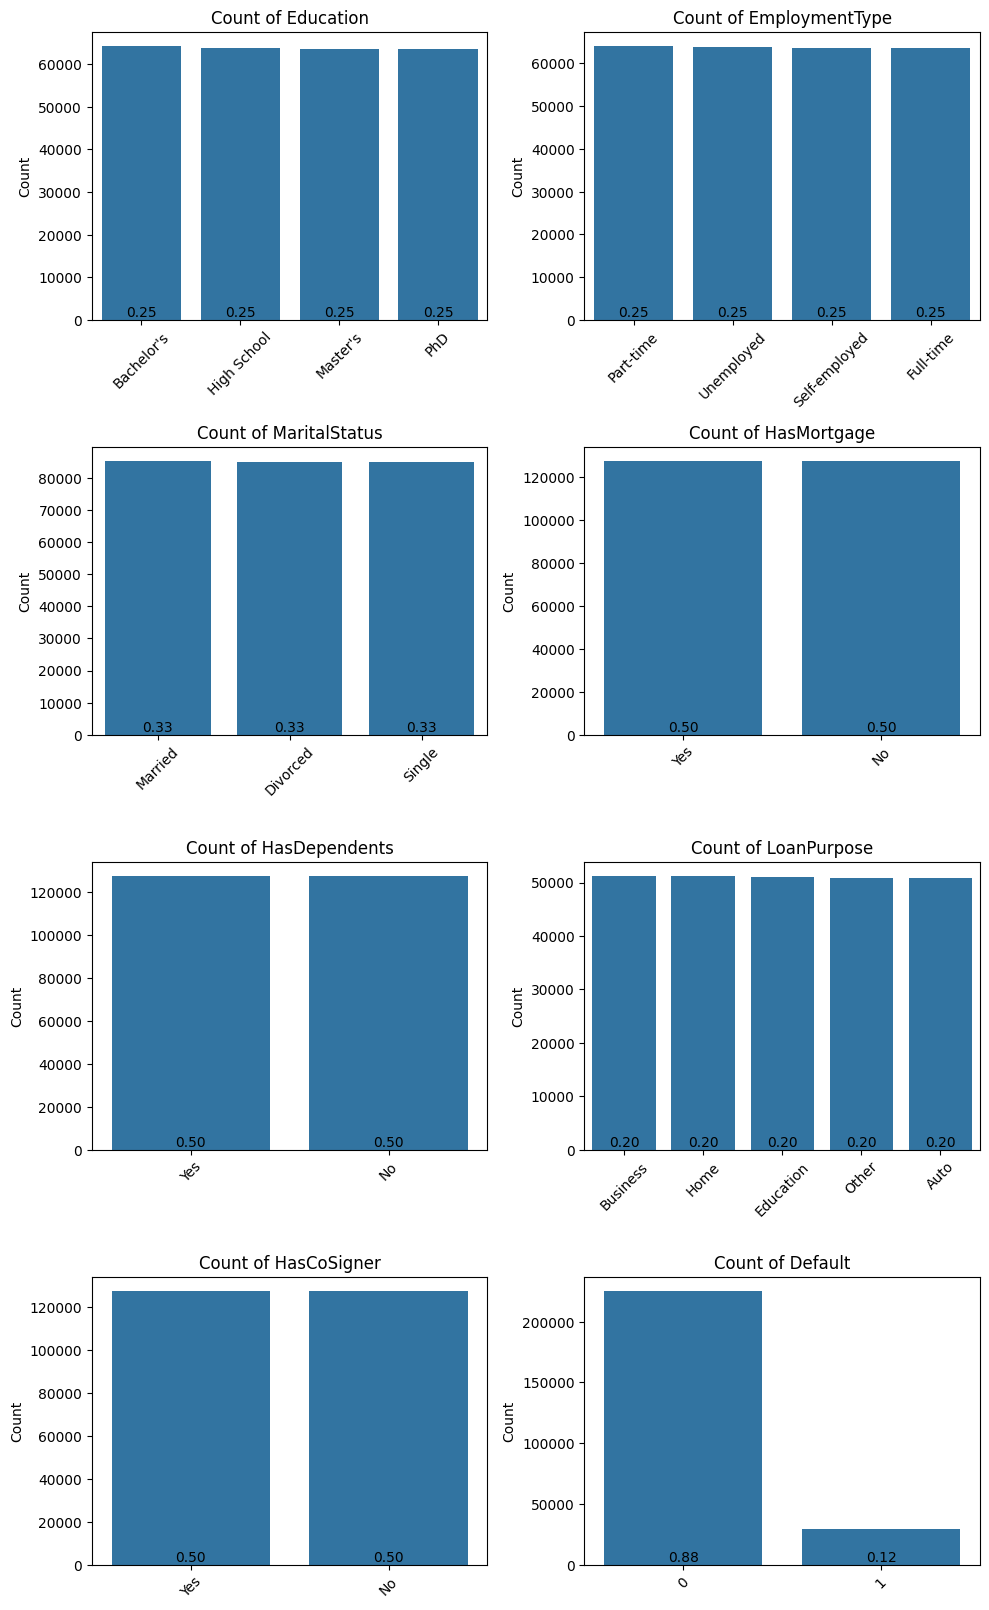

In [17]:
plt.figure(figsize=(10, 20))

for i, col in enumerate(cat_list, start=1):
    # Calculate proportions
    proportions = df[col].value_counts(normalize=True)

    # Plot bar plot
    plt.subplot(5, 2, i)
    sns.countplot(data=df, x=col, order=proportions.index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Count')
    plt.xlabel('')
    for j, count in enumerate(proportions):
        plt.text(j, count, f'{count:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [18]:
#plt.figure(figsize=(13,15))
#plt.subplot(3,2,1)
#sns.boxplot(x ='Age',y ='Income',hue="LoanAmount",data=df)
#plt.legend(loc='upper right')
#plt.subplot(3,2,2)
#sns.boxplot(x="NumCreditLines",y="LoanAmount",data=df)
#plt.subplot(3,2,3)
#sns.boxplot(x="DTIRatio",y="LoanAmount",data=df)
#plt.subplot(3,2,4)
#sns.boxplot(x="Education",y="LoanAmount",data=df)
#plt.tight_layout()

In [19]:
df = df.drop(columns=["LoanID"], axis=1)

In [20]:
# Mapping categorical data
df['Education'] = df['Education'].map({'High School': 1, "Bachelor's": 2, "Master's": 3, 'PhD': 4})
df['EmploymentType'] = df['EmploymentType'].map({'Unemployed': 1, 'Full-time': 2, 'Part-time': 3, 'Self-employed': 4})
df['MaritalStatus'] = df['MaritalStatus'].map({'Married': 1, 'Divorced': 2, 'Single': 3})
df['HasMortgage'] = df['HasMortgage'].map({'No': 0, 'Yes': 1})
df['HasDependents'] = df['HasDependents'].map({'No': 0, 'Yes': 1})
df['LoanPurpose'] = df['LoanPurpose'].map({'Education': 1, 'Auto': 2, 'Home': 3, 'Other': 4, 'Business': 5})
df['HasCoSigner'] = df['HasCoSigner'].map({'No': 0, 'Yes': 1})

In [21]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,28,140466,163781,652,94,2,9.08,48,0.23,1,1,1,0,0,1,0,0
1,28,149227,139759,375,56,3,5.84,36,0.80,4,2,2,0,0,1,1,1
2,41,23265,63527,829,87,4,9.73,60,0.45,3,2,2,1,0,2,1,0
3,53,117550,95744,395,112,4,3.58,24,0.73,1,1,3,0,0,2,1,0
4,57,139699,88143,635,112,4,5.63,48,0.20,3,3,2,0,0,3,0,0


In [22]:
# Save the DataFrame to a CSV file in Colab
df.to_csv('AdjustedData.csv', index=False)

# Download the CSV file to your local machine
# from google.colab import files
# files.download('AdjustedData.csv')

# **Logistic Regression**

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [24]:
df2 = pd.read_csv('AdjustedData.csv')
df2.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,28,140466,163781,652,94,2,9.08,48,0.23,1,1,1,0,0,1,0,0
1,28,149227,139759,375,56,3,5.84,36,0.80,4,2,2,0,0,1,1,1
2,41,23265,63527,829,87,4,9.73,60,0.45,3,2,2,1,0,2,1,0
3,53,117550,95744,395,112,4,3.58,24,0.73,1,1,3,0,0,2,1,0
4,57,139699,88143,635,112,4,5.63,48,0.20,3,3,2,0,0,3,0,0


In [25]:
X = df2.drop(["Default"], axis=1)
y = df2["Default"]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (178728, 16) (178728,)
Testing set shape: (76599, 16) (76599,)


In [26]:
# Initializing the Logistic Regression model
log_reg = LogisticRegression()

In [27]:
# Fitting the model with the training data
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
# Making predictions on the test set
y_pred = log_reg.predict(X_test)

In [29]:
from sklearn.metrics import classification_report

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     67658
           1       0.62      0.01      0.02      8941

    accuracy                           0.88     76599
   macro avg       0.75      0.51      0.48     76599
weighted avg       0.85      0.88      0.83     76599

Accuracy: 0.8838235486102952
Confusion Matrix:
[[67592    66]
 [ 8833   108]]


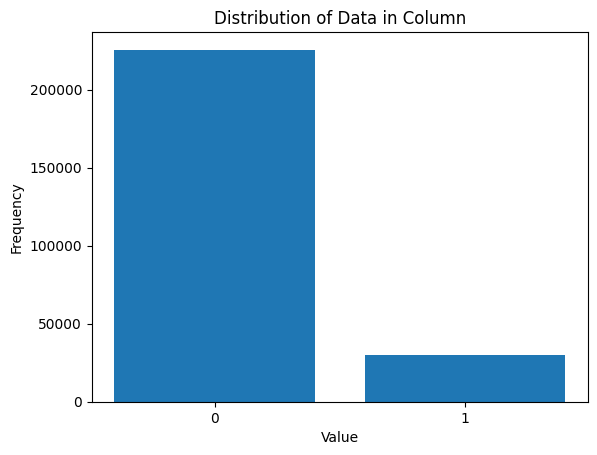

In [50]:
# Count the occurrences of 0s and 1s
counts = df['Default'].value_counts()

# Plot the distribution
plt.bar(counts.index, counts.values)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks([0, 1])
plt.title('Distribution of Data in Column')
plt.show()

**Oversampling**

In [48]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to oversample the minority class in the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Printing the class distribution after oversampling
print("\nOversampled training set class distribution:\n", y_train_resampled.value_counts())



Oversampled training set class distribution:
 Default
0    158021
1    158021
Name: count, dtype: int64


In [32]:
# Fitting the model with the training data
log_reg.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

In [33]:
# Making predictions on the test set
y_pred = log_reg.predict(X_test)

In [34]:
from sklearn.metrics import classification_report

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")

              precision    recall  f1-score   support

           0       0.93      0.67      0.78     67658
           1       0.20      0.62      0.30      8941

    accuracy                           0.67     76599
   macro avg       0.56      0.64      0.54     76599
weighted avg       0.84      0.67      0.72     76599

Accuracy: 0.6650217365761956
Confusion Matrix:
[[45431 22227]
 [ 3432  5509]]


**GridSearchCV**

In [35]:
from sklearn.model_selection import GridSearchCV

# Create a hyperparameter grid to tune
param_grid = {
    'C': np.logspace(-4, 4, 20),  # Regularization strength
    'penalty': ['l1', 'l2'],      # Norm of penalty
    'solver': ['liblinear']        # Algorithm to use for optimization
}

# Initialize GridSearchCV
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1')

# Fit GridSearchCV to the data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# Predict using the best estimator
best_logreg = grid_search.best_estimator_
y_pred = best_logreg.predict(X_test)

# Evaluate the best model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Best hyperparameters: {'C': 1438.44988828766, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.8844501886447603
Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94     67658
           1       0.60      0.03      0.06      8941

    accuracy                           0.88     76599
   macro avg       0.74      0.51      0.50     76599
weighted avg       0.85      0.88      0.84     76599

Confusion Matrix:
 [[67478   180]
 [ 8671   270]]


In [36]:
# Adjust the class weight
log_reg = LogisticRegression(class_weight={0: 1, 1: 10}, penalty='l1', C=4.281332398719396, solver='liblinear')
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.56      0.71     67658
           1       0.19      0.78      0.31      8941

    accuracy                           0.59     76599
   macro avg       0.57      0.67      0.51     76599
weighted avg       0.86      0.59      0.66     76599

[[37967 29691]
 [ 1969  6972]]


# **Naive Bayes**

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [38]:
# Initialize Gaussian Naive Bayes classifier
model = GaussianNB()

# Train the classifier
model.fit(X_train, y_train)

# Make predictions on the test data
predicted = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predicted)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, predicted))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predicted))


Accuracy: 0.8836799436023969

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     67658
           1       0.68      0.01      0.01      8941

    accuracy                           0.88     76599
   macro avg       0.78      0.50      0.48     76599
weighted avg       0.86      0.88      0.83     76599


Confusion Matrix:
[[67631    27]
 [ 8883    58]]


**Oversampling**

In [39]:
# Initialize Gaussian Naive Bayes classifier
model = GaussianNB()

# Train the classifier
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test data
predicted = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predicted)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, predicted))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predicted))


Accuracy: 0.6608702463478635

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.66      0.77     67658
           1       0.21      0.67      0.32      8941

    accuracy                           0.66     76599
   macro avg       0.57      0.67      0.55     76599
weighted avg       0.85      0.66      0.72     76599


Confusion Matrix:
[[44620 23038]
 [ 2939  6002]]


# **Decision Trees**

In [41]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt

In [42]:
# Initialize Decision Tree classifier
model = DecisionTreeClassifier()

# Train the classifier
model.fit(X_train, y_train)

# Make predictions on the test data
predicted = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predicted)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, predicted))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predicted))

# Visualize the decision tree
# plt.figure(figsize=(12, 8))
# tree.plot_tree(model, filled=True)
# plt.show()


Accuracy: 0.8017859240982258

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     67658
           1       0.20      0.23      0.21      8941

    accuracy                           0.80     76599
   macro avg       0.55      0.55      0.55     76599
weighted avg       0.81      0.80      0.81     76599


Confusion Matrix:
[[59376  8282]
 [ 6901  2040]]


**Oversampling**

In [43]:
# Initialize Decision Tree classifier
model = DecisionTreeClassifier()

# Train the classifier
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test data
predicted = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predicted)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, predicted))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predicted))

# Visualize the decision tree
# plt.figure(figsize=(12, 8))
# tree.plot_tree(model, filled=True)
# plt.show()

Accuracy: 0.7487304011801721

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85     67658
           1       0.18      0.32      0.23      8941

    accuracy                           0.75     76599
   macro avg       0.54      0.56      0.54     76599
weighted avg       0.82      0.75      0.78     76599


Confusion Matrix:
[[54455 13203]
 [ 6044  2897]]


**GridSearchCV**

In [45]:
from sklearn.model_selection import GridSearchCV

# Define the Decision Tree Classifier with class_weight parameter
decision_tree = DecisionTreeClassifier(class_weight='balanced')

# Create a hyperparameter grid to tune
params = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2', None]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(decision_tree, params, cv=5, scoring='f1_macro')

In [46]:
# Fit GridSearchCV to the data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and the corresponding best model
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)
best_tree = grid_search.best_estimator_

# Predict using the best model
y_pred = best_tree.predict(X_test)

# Calculate and print the classification report and confusion matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:269: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'`.
  warnings.warn(
/usr/local/lib/pytho

Best hyperparameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.90      0.82      0.86     67658
           1       0.20      0.32      0.24      8941

    accuracy                           0.77     76599
   macro avg       0.55      0.57      0.55     76599
weighted avg       0.82      0.77      0.79     76599

[[55784 11874]
 [ 6047  2894]]
